# BERT Multi-Task ABSA — Aspect Category + Sentiment
Kiến trúc: `Input → BERT (shared encoder) → Head 1: aspect detection → Head 2: sentiment classification`

- **Head 1**: multi-label binary classification — câu thuộc category nào?
- **Head 2**: per-category sentiment (POS / NEG / NEU) — train song song, không tuần tự

In [49]:
!pip install transformers tensorboardX tqdm underthesea -q

## 1. Config
Toàn bộ tham số dự án — chỉ chỉnh tại đây.

In [50]:
import os, sys, random, unicodedata, re
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader, RandomSampler, SequentialSampler
from torch.optim import AdamW
from transformers import AutoModel, AutoTokenizer, get_linear_schedule_with_warmup
from tensorboardX import SummaryWriter
from tqdm.notebook import tqdm, trange
from sklearn.metrics import f1_score, classification_report, confusion_matrix, f1_score as sk_f1
from collections import Counter
from underthesea import word_tokenize

# ── Môi trường ────────────────────────────────────────────────────────────
ON_KAGGLE   = os.path.exists('/kaggle/working')
WORKING_DIR = '/kaggle/working' if ON_KAGGLE else os.getcwd()
print('Environment:', 'Kaggle' if ON_KAGGLE else 'Local')

# ── Model ─────────────────────────────────────────────────────────────────
MODEL_NAME = 'vinai/phobert-base'

# ── Data ──────────────────────────────────────────────────────────────────
if ON_KAGGLE:
    train1     = '/kaggle/input/datasets/conanwinner1/vku-feedback/train1.csv'
    train2     = '/kaggle/input/datasets/conanwinner1/vku-feedback/train2.csv'
    train3     = '/kaggle/input/datasets/conanwinner1/vku-feedback/train3.csv'
    train4     = '/kaggle/input/datasets/conanwinner1/vku-feedback/train4.csv'
    train5     = '/kaggle/input/datasets/conanwinner1/vku-feedback/train5.csv'
    train6     = '/kaggle/input/datasets/conanwinner1/vku-feedback/train6.csv'
    validation = '/kaggle/input/datasets/conanwinner1/vku-feedback/validation.csv'
    test       = '/kaggle/input/datasets/conanwinner1/vku-feedback/test.csv'
else:
    _base      = os.path.join(os.path.dirname(os.getcwd()), 'Final', 'data')
    train1 = train2 = train3 = train4 = train5 = train6 = os.path.join(_base, 'train.csv')
    validation = os.path.join(_base, 'validation.csv')
    test       = os.path.join(_base, 'test.csv')

OUTPUT_DIR = f'{WORKING_DIR}/bert-multitask-acsa'
os.makedirs(OUTPUT_DIR, exist_ok=True)

# ── Aspect Categories ─────────────────────────────────────────────────────
ASPECT_CATEGORIES = [
    'ky_nang_giang_day',    # 0
    'hanh_vi',              # 1
    'de_xuat',              # 2
    'bai_tap',              # 3
    'chuong_trinh_hoc',     # 4
    'kien_thuc',            # 5
    'kinh_nghiem',          # 6
    'cung_cap_tai_lieu',    # 7
    'thiet_bi_day_hoc',     # 8
    'cham_diem',            # 9
    'noi_chung',            # 10
]
NUM_ASPECTS = len(ASPECT_CATEGORIES)
ASPECT2ID   = {a: i for i, a in enumerate(ASPECT_CATEGORIES)}
ID2ASPECT   = {i: a for i, a in enumerate(ASPECT_CATEGORIES)}

# ── Sentiment ─────────────────────────────────────────────────────────────
POLARITIES     = ['negative', 'neutral', 'positive']  # 0, 1, 2
NUM_POLARITIES = len(POLARITIES)
POL2ID         = {p: i for i, p in enumerate(POLARITIES)}
ID2POL         = {i: p for i, p in enumerate(POLARITIES)}
IGNORE_INDEX   = -100

# ── Training ──────────────────────────────────────────────────────────────
SEED             = 42
MAX_EPOCHS       = 10
TRAIN_BATCH_SIZE = 16
EVAL_BATCH_SIZE  = 32
LEARNING_RATE    = 2e-5
WARMUP_RATIO     = 0.1
MAX_SEQ_LENGTH   = 128
WEIGHT_DECAY     = 0.01
PATIENCE         = 2      # early stopping: dừng nếu val_f1 không tăng sau N epochs

# ── Multi-task loss weights ───────────────────────────────────────────────
ALPHA = 1.0
BETA  = 1.0

# ── Logging ───────────────────────────────────────────────────────────────
LOG_STEPS  = 50
SAVE_STEPS = 200

print(f'Model     : {MODEL_NAME}')
print(f'Categories: {NUM_ASPECTS}')
print(f'Output    : {OUTPUT_DIR}')


Environment: Kaggle
Model     : vinai/phobert-base
Categories: 11
Output    : /kaggle/working/bert-multitask-acsa


## 2. Kiểm tra GPU

In [51]:
print('PyTorch:', torch.__version__)
print('CUDA:', torch.cuda.is_available())
if torch.cuda.is_available():
    print('GPU:', torch.cuda.get_device_name(0))
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
n_gpu  = torch.cuda.device_count()

tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)
print('Tokenizer loaded:', MODEL_NAME)


PyTorch: 2.10.0+cu128
CUDA: True
GPU: Tesla T4
Tokenizer loaded: vinai/phobert-base


## 3. Data — Convert CSV → Category CSV

## 3.1. Word Segmentation (PhoBERT yêu cầu)

In [52]:
def preprocess_text(text):
    """
    Tiền xử lý cho PhoBERT:
    1. Chuẩn hóa Unicode NFC
    2. Trim whitespace thừa, chuẩn hóa dấu câu đầu câu
    3. Word segmentation → underscore (giảng viên → giảng_viên)
    """
    # 1. Unicode NFC
    text = unicodedata.normalize('NFC', str(text).strip())

    # 2. Bỏ dấu chấm/khoảng trắng thừa ở đầu câu (vd: ". Thầy...")
    text = re.sub(r'^[\s\.\-]+', '', text)

    # 3. Word segmentation
    text = word_tokenize(text, format='text')   # "giảng viên" → "giảng_viên"

    return text


# Test thử
samples_test = [
    'Giảng viên rất nhiệt tình và tài năng.',
    'Phòng học quá nóng, không có điều hòa.',
    '. Thầy/cô luôn tôn trọng sinh viên.',
]
print('Word segmentation examples:')
for s in samples_test:
    print(f'  Before: {s}')
    print(f'  After : {preprocess_text(s)}')
    print()


Word segmentation examples:
  Before: Giảng viên rất nhiệt tình và tài năng.
  After : Giảng_viên rất nhiệt_tình và tài_năng .

  Before: Phòng học quá nóng, không có điều hòa.
  After : Phòng học quá nóng , không có điều hòa .

  Before: . Thầy/cô luôn tôn trọng sinh viên.
  After : Thầy / cô luôn tôn_trọng sinh_viên .



In [53]:
df_train1 = pd.read_csv(train1)
df_train2 = pd.read_csv(train2)
df_train3 = pd.read_csv(train3)
df_train4 = pd.read_csv(train4)
df_train5 = pd.read_csv(train5)
df_train6 = pd.read_csv(train6)

df_validation = pd.read_csv(validation)
df_test = pd.read_csv(test)

print(df_train1.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3086 entries, 0 to 3085
Data columns (total 4 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   id         3086 non-null   int64 
 1   text       3086 non-null   object
 2   sentiment  3086 non-null   object
 3   aspect     3086 non-null   object
dtypes: int64(1), object(3)
memory usage: 96.6+ KB
None


In [54]:
df = pd.concat([df_train1, df_train2, df_train3, df_train4, df_train5, df_train6], ignore_index=True)

In [55]:
df.head(5)

,id,text,sentiment,aspect
0,1,slide giáo trình đầy đủ .,positive,cung_cap_tai_lieu
1,2,"nhiệt tình giảng dạy , gần gũi với sinh viên .",positive,ky_nang_giang_day
2,2,"nhiệt tình giảng dạy , gần gũi với sinh viên .",positive,hanh_vi
3,3,đi học đầy đủ full điểm chuyên cần .,neutral,noi_chung
4,4,chưa áp dụng công nghệ thông tin và các thiết ...,negative,thiet_bi_day_hoc


In [56]:
print(df.value_counts("aspect"))

aspect
ky_nang_giang_day    4546
hanh_vi              4474
de_xuat              2044
bai_tap              1241
chuong_trinh_hoc      989
kien_thuc             867
kinh_nghiem           652
cung_cap_tai_lieu     646
thiet_bi_day_hoc      564
noi_chung             546
cham_diem             314
Name: count, dtype: int64


In [57]:
print(df.value_counts("sentiment"))

sentiment
positive    8448
negative    5939
neutral     2496
Name: count, dtype: int64


In [58]:
min_len = df['text'].str.len().min()
max_len = df['text'].str.len().max()

print("Min length:", min_len)
print("Max length:", max_len)

Min length: 4
Max length: 660


In [59]:
df['text'].str.len().describe()

count    16883.000000
mean        66.861636
std         48.829144
min          4.000000
25%         35.000000
50%         53.000000
75%         83.000000
max        660.000000
Name: text, dtype: float64

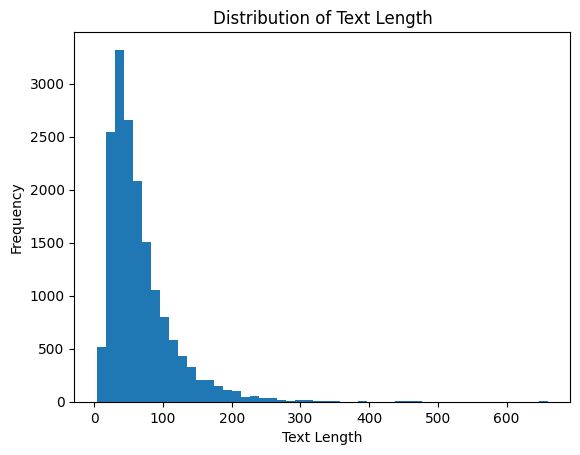

In [60]:
import matplotlib.pyplot as plt

lengths = df['text'].str.len()

plt.figure()
plt.hist(lengths, bins=50)
plt.title("Distribution of Text Length")
plt.xlabel("Text Length")
plt.ylabel("Frequency")
plt.show()

In [61]:
token_lens = []
for text in df['text']:
    processed = preprocess_text(text)   # phải preprocess trước như lúc train
    tokens = tokenizer.encode(processed, add_special_tokens=True)
    token_lens.append(len(tokens))

pd.Series(token_lens).describe()


count    16883.000000
mean        14.972043
std          9.644151
min          4.000000
25%          9.000000
50%         12.000000
75%         18.000000
max        129.000000
dtype: float64

In [62]:
import numpy as np

print("90%:", np.percentile(token_lens, 90))
print("95%:", np.percentile(token_lens, 95))
print("99%:", np.percentile(token_lens, 99))
print("max:", max(token_lens))

90%: 26.0
95%: 34.0
99%: 51.0
max: 129


In [63]:
def load_acsa_data(df_file):
    """
    Group theo id → mỗi sample:
      - text      : str (đã preprocess)
      - aspect    : (NUM_ASPECTS,) float multi-hot
      - sentiment : (NUM_ASPECTS,) int, IGNORE_INDEX nếu absent
    """
    df = df_file
    samples = []
    skipped = 0

    for sent_id, group in df.groupby('id'):
        text = preprocess_text(group.iloc[0]['text'])

        aspect_labels    = np.zeros(NUM_ASPECTS, dtype=np.float32)
        sentiment_labels = np.full(NUM_ASPECTS, IGNORE_INDEX, dtype=np.int64)

        for _, row in group.iterrows():
            asp_str = str(row['aspect']).strip()
            sen_str = str(row['sentiment']).strip()

            if asp_str not in ASPECT2ID:
                skipped += 1
                continue
            if sen_str not in POL2ID:
                skipped += 1
                continue

            asp_idx = ASPECT2ID[asp_str]
            sen_idx = POL2ID[sen_str]

            aspect_labels[asp_idx] = 1.0
            if sentiment_labels[asp_idx] == IGNORE_INDEX:
                sentiment_labels[asp_idx] = sen_idx

        samples.append({
            'id':       sent_id,
            'text':     text,
            'aspect':   aspect_labels,
            'sentiment': sentiment_labels,
        })

    if skipped:
        print(f'  ⚠️  Skipped {skipped} rows with unknown aspect/sentiment labels')
    return samples


def print_stats(samples, split_name):
    print(f'=====================================================')
    print(f'  {split_name}: {len(samples)} sentences')
    print(f'=====================================================')
    aspect_counts = np.zeros(NUM_ASPECTS)
    pol_counts    = Counter()
    for s in samples:
        aspect_counts += s['aspect']
        for i, v in enumerate(s['sentiment']):
            if v != IGNORE_INDEX:
                pol_counts[ID2POL[v]] += 1
    print('  Aspect distribution:')
    max_cnt = aspect_counts.max()
    for i, cat in enumerate(ASPECT_CATEGORIES):
        cnt = int(aspect_counts[i])
        bar = '█' * int(30 * cnt / (max_cnt or 1))
        print(f'    {i:2d}. {cat:<25s} {cnt:4d}  {bar}')
    print('\n  Polarity distribution:')
    total_pol = sum(pol_counts.values())
    for pol in POLARITIES:
        cnt = pol_counts[pol]
        bar = '█' * int(30 * cnt / (total_pol or 1))
        print(f'    {pol:<12s} {cnt:4d} ({100*cnt/(total_pol or 1):.1f}%)  {bar}')


load_train1 = load_acsa_data(df_train1)
load_train2 = load_acsa_data(df_train2)
load_train3 = load_acsa_data(df_train3)
load_train4 = load_acsa_data(df_train4)
load_train5 = load_acsa_data(df_train5)
load_train6 = load_acsa_data(df_train6)

train_s = load_train1 + load_train2 + load_train3 + load_train4 + load_train5 + load_train6
dev_s   = load_acsa_data(df_validation)
test_s  = load_acsa_data(df_test)

# Bỏ 'id' khỏi samples sau khi load xong
for split in [train_s, dev_s, test_s]:
    for item in split:
        item.pop('id', None)

print_stats(train_s, 'Train')
print_stats(dev_s,   'Dev')
print_stats(test_s,  'Test')


# ── Verify IGNORE_INDEX ───────────────────────────────────────────────────
def verify_labels(samples, split_name):
    errors = 0
    for s in samples:
        for i in range(NUM_ASPECTS):
            asp = s['aspect'][i]
            sen = s['sentiment'][i]
            if asp == 0 and sen != IGNORE_INDEX:
                errors += 1
            if asp == 1 and sen not in [0, 1, 2]:
                errors += 1
    status = '✓' if errors == 0 else f'⚠️  {errors} errors'
    print(f'  {split_name} label check: {status}')

verify_labels(train_s, 'Train')
verify_labels(dev_s,   'Dev')
verify_labels(test_s,  'Test')


  Train: 11389 sentences
  Aspect distribution:
     0. ky_nang_giang_day         4546  ██████████████████████████████
     1. hanh_vi                   4474  █████████████████████████████
     2. de_xuat                   2044  █████████████
     3. bai_tap                   1241  ████████
     4. chuong_trinh_hoc           989  ██████
     5. kien_thuc                  867  █████
     6. kinh_nghiem                652  ████
     7. cung_cap_tai_lieu          646  ████
     8. thiet_bi_day_hoc           564  ███
     9. cham_diem                  314  ██
    10. noi_chung                  546  ███

  Polarity distribution:
    negative     5939 (35.2%)  ██████████
    neutral      2496 (14.8%)  ████
    positive     8448 (50.0%)  ███████████████
  Dev: 1575 sentences
  Aspect distribution:
     0. ky_nang_giang_day          624  ██████████████████████████████
     1. hanh_vi                    608  █████████████████████████████
     2. de_xuat                    278  █████████████
   

## 4. Dataset & DataLoader — từ Category CSV

In [64]:
class ACSADataset(Dataset):
    def __init__(self, samples, tokenizer, max_len):
        self.samples   = samples
        self.tokenizer = tokenizer
        self.max_len   = max_len

    def __len__(self): return len(self.samples)

    def __getitem__(self, idx):
        s   = self.samples[idx]
        enc = self.tokenizer(
            s['text'],
            max_length=self.max_len,
            padding='max_length',
            truncation=True,
            return_tensors='pt',
        )
        return {
            'input_ids':        enc['input_ids'].squeeze(0),
            'attention_mask':   enc['attention_mask'].squeeze(0),
            'aspect_labels':    torch.tensor(s['aspect'],    dtype=torch.float),
            'sentiment_labels': torch.tensor(s['sentiment'], dtype=torch.long),
        }


train_dataset = ACSADataset(train_s, tokenizer, MAX_SEQ_LENGTH)
dev_dataset   = ACSADataset(dev_s,   tokenizer, MAX_SEQ_LENGTH)
test_dataset  = ACSADataset(test_s,  tokenizer, MAX_SEQ_LENGTH)

train_loader = DataLoader(train_dataset, sampler=RandomSampler(train_dataset),     batch_size=TRAIN_BATCH_SIZE)
dev_loader   = DataLoader(dev_dataset,   sampler=SequentialSampler(dev_dataset),   batch_size=EVAL_BATCH_SIZE)
test_loader  = DataLoader(test_dataset,  sampler=SequentialSampler(test_dataset),  batch_size=EVAL_BATCH_SIZE)

print(f'Train: {len(train_dataset)} | Dev: {len(dev_dataset)} | Test: {len(test_dataset)} sentences')


Train: 11389 | Dev: 1575 | Test: 3160 sentences


## 5. Model — BertMultiTaskABSA

In [65]:
# ── Tính pos_weight (clip max=20, sqrt để tránh quá mạnh) ────────────────
all_asp    = np.array([s['aspect'] for s in train_s])
pos_counts = all_asp.sum(axis=0)
neg_counts = len(all_asp) - pos_counts
# pw_raw     = neg_counts / (pos_counts + 1e-8)
# pw_clipped = np.clip(pw_raw, 1.0, 20.0)          # clip max 20

pw_raw = neg_counts / (pos_counts + 1e-8)
pw_sqrt = np.sqrt(pw_raw)
pw_clipped = np.clip(pw_sqrt, 1.0, 20.0)
pw = torch.tensor(pw_clipped, dtype=torch.float)

pw         = torch.tensor(pw_clipped, dtype=torch.float)
print('pos_weight (clipped):', pw.numpy().round(1))


def mean_pooling(last_hidden_state, attention_mask):
    """Mean pooling theo attention mask — ổn định hơn pooler_output."""
    mask   = attention_mask.unsqueeze(-1).float()          # (B, L, 1)
    summed = (last_hidden_state * mask).sum(dim=1)         # (B, H)
    counts = mask.sum(dim=1).clamp(min=1e-9)               # (B, 1)
    return summed / counts                                  # (B, H)


class BertMultiTaskABSA(nn.Module):
    def __init__(self, model_name, num_aspects, num_polarities, pos_weight, dropout=0.1):
        super().__init__()
        self.encoder        = AutoModel.from_pretrained(model_name)
        hidden              = self.encoder.config.hidden_size
        self.dropout        = nn.Dropout(dropout)
        self.aspect_head    = nn.Linear(hidden, num_aspects)
        self.sentiment_head = nn.Linear(hidden, num_aspects * num_polarities)
        self.num_aspects    = num_aspects
        self.num_polarities = num_polarities
        self.register_buffer('pos_weight', pos_weight)

    def forward(self, input_ids, attention_mask,
                aspect_labels=None, sentiment_labels=None):
        outputs = self.encoder(input_ids=input_ids, attention_mask=attention_mask)

        # mean pooling thay vì pooler_output
        pooled  = mean_pooling(outputs.last_hidden_state, attention_mask)
        pooled  = self.dropout(pooled)

        asp_logits  = self.aspect_head(pooled)
        sent_logits = self.sentiment_head(pooled).view(-1, self.num_aspects, self.num_polarities)

        loss = None
        if aspect_labels is not None and sentiment_labels is not None:
            loss_aspect = nn.BCEWithLogitsLoss(pos_weight=self.pos_weight)(asp_logits, aspect_labels)
            loss_sent   = nn.CrossEntropyLoss(ignore_index=IGNORE_INDEX)(
                sent_logits.view(-1, self.num_polarities),
                sentiment_labels.view(-1),
            )
            loss = ALPHA * loss_aspect + BETA * loss_sent

        return loss, asp_logits, sent_logits


import sys, os
if not hasattr(sys.modules['__main__'], '__file__'):
    dummy = os.path.abspath('dummy_fix.py')
    open(dummy, 'w').close()
    sys.modules['__main__'].__file__ = dummy

model = BertMultiTaskABSA(MODEL_NAME, NUM_ASPECTS, NUM_POLARITIES, pos_weight=pw)
model.to(device)
if n_gpu > 1:
    model = nn.DataParallel(model)

print(f'✓ Model loaded | Params: {sum(p.numel() for p in model.parameters() if p.requires_grad):,}')


pos_weight (clipped): [1.2 1.2 2.1 2.9 3.2 3.5 4.1 4.1 4.4 5.9 4.5]


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

RobertaModel LOAD REPORT from: vinai/phobert-base
Key                             | Status     |  | 
--------------------------------+------------+--+-
lm_head.dense.bias              | UNEXPECTED |  | 
roberta.embeddings.position_ids | UNEXPECTED |  | 
lm_head.dense.weight            | UNEXPECTED |  | 
lm_head.decoder.bias            | UNEXPECTED |  | 
lm_head.layer_norm.bias         | UNEXPECTED |  | 
lm_head.layer_norm.weight       | UNEXPECTED |  | 
lm_head.bias                    | UNEXPECTED |  | 
lm_head.decoder.weight          | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


✓ Model loaded | Params: 135,032,108


## 6. Training

In [66]:
def evaluate_model(model, loader):
    model.eval()
    total_loss   = 0.0
    all_asp_gold, all_asp_pred = [], []
    all_sen_gold, all_sen_pred = [], []

    with torch.no_grad():
        for batch in tqdm(loader, desc='Evaluating', leave=False):
            input_ids        = batch['input_ids'].to(device)
            attention_mask   = batch['attention_mask'].to(device)
            aspect_labels    = batch['aspect_labels'].to(device)
            sentiment_labels = batch['sentiment_labels'].to(device)

            loss, asp_logits, sent_logits = model(
                input_ids, attention_mask,
                aspect_labels, sentiment_labels)
            if n_gpu > 1: loss = loss.mean()
            total_loss += loss.item()

            # Aspect: threshold 0.5
            asp_pred = (torch.sigmoid(asp_logits) > 0.5).cpu().numpy().astype(int)
            asp_gold = aspect_labels.cpu().numpy().astype(int)
            all_asp_gold.append(asp_gold)
            all_asp_pred.append(asp_pred)

            # Sentiment: argmax, chỉ tính ở vị trí present
            sent_pred = torch.argmax(sent_logits, dim=-1).cpu().numpy()  # (B, A)
            sent_gold = sentiment_labels.cpu().numpy()                    # (B, A)
            mask      = sent_gold != IGNORE_INDEX
            all_sen_gold.extend(sent_gold[mask].tolist())
            all_sen_pred.extend(sent_pred[mask].tolist())

    all_asp_gold = np.vstack(all_asp_gold)
    all_asp_pred = np.vstack(all_asp_pred)

    aspect_f1 = f1_score(all_asp_gold, all_asp_pred, average='micro', zero_division=0)
    sent_f1   = f1_score(all_sen_gold, all_sen_pred, average='macro', zero_division=0)

    return {
        'loss':      total_loss / len(loader),
        'aspect_f1': aspect_f1,
        'sent_f1':   sent_f1,
        'asp_gold':  all_asp_gold,
        'asp_pred':  all_asp_pred,
        'sen_gold':  all_sen_gold,
        'sen_pred':  all_sen_pred,
    }


In [67]:
def set_seed(seed):
    random.seed(seed); np.random.seed(seed); torch.manual_seed(seed)
    if torch.cuda.is_available(): torch.cuda.manual_seed_all(seed)

set_seed(SEED)

t_total      = len(train_loader) * MAX_EPOCHS
warmup_steps = int(t_total * WARMUP_RATIO)

no_decay  = ['bias', 'LayerNorm.weight']
optimizer = AdamW([
    {'params': [p for n,p in model.named_parameters() if not any(nd in n for nd in no_decay)], 'weight_decay': WEIGHT_DECAY},
    {'params': [p for n,p in model.named_parameters() if     any(nd in n for nd in no_decay)], 'weight_decay': 0.0},
], lr=LEARNING_RATE, eps=1e-8)
scheduler = get_linear_schedule_with_warmup(optimizer, warmup_steps, t_total)

tb_writer   = SummaryWriter(log_dir=OUTPUT_DIR)
global_step = 0
history     = {'epoch': [], 'train_loss': [], 'val_loss': [], 'val_aspect_f1': [], 'val_sent_f1': [], 'val_combined_f1': []}

# Early stopping
best_val_f1    = 0.0
patience_count = 0
best_ckpt_path = os.path.join(OUTPUT_DIR, 'best_model.pt')

for epoch in trange(MAX_EPOCHS, desc='Epoch'):
    model.train()
    epoch_loss, epoch_steps = 0.0, 0

    for batch in tqdm(train_loader, desc=f'Train E{epoch+1}', leave=False):
        input_ids        = batch['input_ids'].to(device)
        attention_mask   = batch['attention_mask'].to(device)
        aspect_labels    = batch['aspect_labels'].to(device)
        sentiment_labels = batch['sentiment_labels'].to(device)

        loss, _, _ = model(input_ids, attention_mask, aspect_labels, sentiment_labels)
        if n_gpu > 1: loss = loss.mean()

        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
        optimizer.step(); scheduler.step(); model.zero_grad()

        epoch_loss  += loss.item()
        epoch_steps += 1
        global_step += 1

        if global_step % LOG_STEPS == 0:
            tb_writer.add_scalar('train_loss', loss.item(), global_step)
            tb_writer.add_scalar('lr', scheduler.get_last_lr()[0], global_step)

        if global_step % SAVE_STEPS == 0:
            ckpt = os.path.join(OUTPUT_DIR, f'checkpoint-{global_step}')
            os.makedirs(ckpt, exist_ok=True)
            m = model.module if hasattr(model, 'module') else model
            torch.save(m.state_dict(), os.path.join(ckpt, 'model.pt'))

    # ── Eval cuối epoch ──────────────────────────────────────────────────
    val_metrics = evaluate_model(model, dev_loader)
    avg_train   = epoch_loss / epoch_steps

    history['epoch'].append(epoch + 1)
    history['train_loss'].append(avg_train)
    history['val_loss'].append(val_metrics['loss'])
    history['val_aspect_f1'].append(val_metrics['aspect_f1'])
    history['val_sent_f1'].append(val_metrics['sent_f1'])
    # Combined metric: geometric mean of aspect_f1 and sent_f1
    combined_f1 = (val_metrics['aspect_f1'] * val_metrics['sent_f1']) ** 0.5
    history['val_combined_f1'].append(combined_f1)

    tb_writer.add_scalar('val_loss',      val_metrics['loss'],      global_step)
    tb_writer.add_scalar('val_aspect_f1', val_metrics['aspect_f1'], global_step)
    tb_writer.add_scalar('val_sent_f1',   val_metrics['sent_f1'],   global_step)
    tb_writer.add_scalar('val_combined_f1', combined_f1,              global_step)

    print(f"[Epoch {epoch+1}] train_loss={avg_train:.4f} | "
          f"val_loss={val_metrics['loss']:.4f} | "
          f"aspect_f1={val_metrics['aspect_f1']:.4f} | "
          f"sent_f1={val_metrics['sent_f1']:.4f} | "
          f"combined_f1={combined_f1:.4f}")

    # ── Lưu best model (dựa trên combined metric: geometric mean) ───────
    if combined_f1 > best_val_f1:
        best_val_f1 = combined_f1
        patience_count = 0
        m = model.module if hasattr(model, 'module') else model
        torch.save(m.state_dict(), best_ckpt_path)
        print(f'  ✓ Best model saved (combined_f1={best_val_f1:.4f}  |  asp={val_metrics["aspect_f1"]:.4f}  sent={val_metrics["sent_f1"]:.4f})')
    else:
        patience_count += 1
        print(f'  No improvement ({patience_count}/{PATIENCE})')
        if patience_count >= PATIENCE:
            print(f'  Early stopping at epoch {epoch+1}')
            break

tb_writer.close()
# Lưu model cuối
m = model.module if hasattr(model, 'module') else model
torch.save(m.state_dict(), os.path.join(OUTPUT_DIR, 'model_final.pt'))
print(f'\n✓ Training done. Best val_combined_f1={best_val_f1:.4f}')
print(f'  Best model: {best_ckpt_path}')
print(f'  Final model: {OUTPUT_DIR}/model_final.pt')


Epoch:   0%|          | 0/10 [00:00<?, ?it/s]

Train E1:   0%|          | 0/712 [00:00<?, ?it/s]

/usr/local/lib/python3.12/dist-packages/torch/autograd/function.py:583: UserWarning: Was asked to gather along dimension 0, but all input tensors were scalars; will instead unsqueeze and return a vector.
  return super().apply(*args, **kwargs)  # type: ignore[misc]


Evaluating:   0%|          | 0/50 [00:00<?, ?it/s]

[Epoch 1] train_loss=1.1992 | val_loss=0.7803 | aspect_f1=0.6822 | sent_f1=0.8459 | combined_f1=0.7597
  ✓ Best model saved (combined_f1=0.7597  |  asp=0.6822  sent=0.8459)


...

Evaluating:   0%|          | 0/50 [00:00<?, ?it/s]

[Epoch 2] train_loss=0.6709 | val_loss=0.5853 | aspect_f1=0.8272 | sent_f1=0.8559 | combined_f1=0.8415
  ✓ Best model saved (combined_f1=0.8415  |  asp=0.8272  sent=0.8559)


Train E3:   0%|          | 0/712 [00:00<?, ?it/s]

/usr/local/lib/python3.12/dist-packages/torch/autograd/function.py:583: UserWarning: Was asked to gather along dimension 0, but all input tensors were scalars; will instead unsqueeze and return a vector.
  return super().apply(*args, **kwargs)  # type: ignore[misc]


KeyboardInterrupt: 

## 7. Evaluation

In [ ]:
print('=== Dev ===')
dev_metrics  = evaluate_model(model, dev_loader)
print(f"aspect_f1={dev_metrics['aspect_f1']:.4f} | sent_f1={dev_metrics['sent_f1']:.4f}")

print('\n=== Test ===')
test_metrics = evaluate_model(model, test_loader)
print(f"aspect_f1={test_metrics['aspect_f1']:.4f} | sent_f1={test_metrics['sent_f1']:.4f}")

# Per-category sentiment report
print('\nPer-class Sentiment (Test):')
print(classification_report(
    test_metrics['sen_gold'], test_metrics['sen_pred'],
    target_names=POLARITIES, zero_division=0))


## 8. Visualization

In [ ]:
# ── 1. Learning curves (overfit / underfit) ───────────────────────────────
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 5))
fig.suptitle('Learning Curves', fontsize=14, fontweight='bold')

epochs = history['epoch']
ax1.plot(epochs, history['train_loss'], 'o-',  color='#3498db', label='Train Loss', lw=2)
ax1.plot(epochs, history['val_loss'],   's--', color='#e74c3c', label='Val Loss',   lw=2)
gap = history['val_loss'][-1] - history['train_loss'][-1]
ax1.annotate(f'gap={gap:+.3f}',
             xy=(epochs[-1], history['val_loss'][-1]),
             xytext=(-40, 12), textcoords='offset points',
             arrowprops=dict(arrowstyle='->', color='gray'), fontsize=9, color='#e74c3c')
ax1.set_xlabel('Epoch'); ax1.set_ylabel('Loss'); ax1.set_title('Loss per Epoch')
ax1.legend(); ax1.grid(True, linestyle='--', alpha=0.5); ax1.set_axisbelow(True)

best_epoch = epochs[history['val_combined_f1'].index(max(history['val_combined_f1']))]
best_f1    = max(history['val_combined_f1'])
ax2.plot(epochs, history['val_aspect_f1'],   's-', color='#2ecc71', lw=2, label='Val Aspect F1')
ax2.plot(epochs, history['val_sent_f1'],     'o-', color='#e67e22', lw=2, label='Val Sent F1')
ax2.plot(epochs, history['val_combined_f1'], 'D-', color='#9b59b6', lw=2, label='Val Combined F1')
ax2.axvline(best_epoch, color='gray', linestyle=':', lw=1.5)
ax2.scatter([best_epoch], [best_f1], color='#f39c12', zorder=5, s=80,
            label=f'Best Combined={best_f1:.3f} @ ep{best_epoch}')
ax2.set_xlabel('Epoch'); ax2.set_ylabel('F1 Score'); ax2.set_title('Val F1 Metrics per Epoch (Combined = Geometric Mean)')
ax2.legend(fontsize=8); ax2.grid(True, linestyle='--', alpha=0.5); ax2.set_axisbelow(True)

plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, 'learning_curves.png'), dpi=150, bbox_inches='tight')
plt.show()

if gap > 0.3:
    print(f"⚠️  Overfit: gap={gap:.3f} — thử tăng dropout hoặc giảm MAX_EPOCHS.")
elif best_f1 < 0.5:
    print(f"⚠️  Underfit: best_f1={best_f1:.3f} — thử tăng MAX_EPOCHS hoặc giảm LR.")
else:
    print(f"✓  Fit tốt: gap={gap:.3f}, best aspect_f1={best_f1:.3f} @ epoch {best_epoch}.")

# ── 2. Dev vs Test metrics bar chart ─────────────────────────────────────
metric_keys = ['aspect_f1', 'sent_f1', 'loss']
summary = pd.DataFrame([
    {'Split': 'Dev',  **{k: round(dev_metrics[k],  4) for k in metric_keys}},
    {'Split': 'Test', **{k: round(test_metrics[k], 4) for k in metric_keys}},
])
print('\nMetrics summary:')
print(summary.to_string(index=False))

plot_keys = ['aspect_f1', 'sent_f1']
x      = np.arange(len(plot_keys))
width  = 0.32
fig, ax = plt.subplots(figsize=(7, 5))
for i, (split, metrics) in enumerate([('Dev', dev_metrics), ('Test', test_metrics)]):
    scores = [metrics[k] for k in plot_keys]
    bars   = ax.bar(x + (i - 0.5) * width, scores, width,
                    label=split, color=['#3498db','#e74c3c'][i], alpha=0.85)
    ax.bar_label(bars, fmt='%.3f', fontsize=9, padding=3)
ax.set_xticks(x); ax.set_xticklabels(['Aspect F1 (micro)', 'Sentiment F1 (macro)'], fontsize=10)
ax.set_ylim(0, 1.1); ax.set_ylabel('Score')
ax.set_title('Dev vs Test Metrics')
ax.legend(); ax.yaxis.grid(True, linestyle='--', alpha=0.5); ax.set_axisbelow(True)
plt.tight_layout(); plt.show()

# ── 3. Per-category Aspect F1 (Test) ─────────────────────────────────────
per_cat_f1 = [
    sk_f1(test_metrics['asp_gold'][:, i], test_metrics['asp_pred'][:, i], zero_division=0)
    for i in range(NUM_ASPECTS)
]
short_labels = [c.replace('_', ' ') for c in ASPECT_CATEGORIES]  # underscore → space

fig, ax = plt.subplots(figsize=(12, 4))
bars = ax.bar(short_labels, per_cat_f1, color='#3498db', alpha=0.85)
ax.bar_label(bars, fmt='%.2f', fontsize=8, padding=3)
ax.set_ylim(0, 1.15); ax.set_ylabel('F1')
ax.set_title('Aspect Detection F1 per Category (Test)')
ax.yaxis.grid(True, linestyle='--', alpha=0.5); ax.set_axisbelow(True)
plt.xticks(rotation=30, ha='right', fontsize=9)
plt.tight_layout(); plt.show()

# ── 4. Sentiment confusion matrix (Test) ─────────────────────────────────
cm      = confusion_matrix(test_metrics['sen_gold'], test_metrics['sen_pred'],
                           labels=list(range(NUM_POLARITIES)))
cm_norm = cm.astype(float) / cm.sum(axis=1, keepdims=True)
annots  = np.array([[f'{cm[i,j]}\n({cm_norm[i,j]:.0%})' for j in range(NUM_POLARITIES)]
                    for i in range(NUM_POLARITIES)])

fig, ax = plt.subplots(figsize=(7, 5))
sns.heatmap(cm_norm, annot=annots, fmt='', cmap='Blues', ax=ax,
            xticklabels=POLARITIES, yticklabels=POLARITIES,
            vmin=0, vmax=1, linewidths=1.5, linecolor='white',
            annot_kws={'size': 11, 'weight': 'bold'})
for i in range(NUM_POLARITIES):
    ax.add_patch(plt.Rectangle((i, i), 1, 1, fill=False, edgecolor='#2ecc71', lw=2.5))
ax.set_title('Sentiment Confusion Matrix (Test)', fontsize=12, fontweight='bold')
ax.set_ylabel('Gold'); ax.set_xlabel('Predicted')
ax.set_yticklabels(ax.get_yticklabels(), rotation=0)
plt.tight_layout(); plt.show()

# ── 5. Per-class sentiment report ────────────────────────────────────────
from sklearn.metrics import classification_report
print('\nPer-class Sentiment (Test):')
print(classification_report(
    test_metrics['sen_gold'], test_metrics['sen_pred'],
    target_names=POLARITIES, zero_division=0))


## 9. Inference

In [ ]:
def find_best_threshold(model, loader, thresholds=None):
    """Tune threshold per-category trên validation set."""
    if thresholds is None:
        thresholds = [0.3, 0.4, 0.5, 0.6]
    
    model.eval()
    all_asp_gold, all_asp_logits = [], []
    with torch.no_grad():
        for batch in loader:
            input_ids      = batch['input_ids'].to(device)
            attention_mask = batch['attention_mask'].to(device)
            _, asp_logits, _ = model(input_ids, attention_mask)
            all_asp_logits.append(torch.sigmoid(asp_logits).cpu().numpy())
            all_asp_gold.append(batch['aspect_labels'].numpy())
    
    logits = np.vstack(all_asp_logits)   # (N, NUM_ASPECTS)
    gold   = np.vstack(all_asp_gold)     # (N, NUM_ASPECTS)
    
    from sklearn.metrics import f1_score
    best_thresh = 0.5
    best_f1     = 0.0
    for t in thresholds:
        preds = (logits > t).astype(int)
        f1    = f1_score(gold, preds, average='micro', zero_division=0)
        print(f'  threshold={t:.2f} → aspect_f1={f1:.4f}')
        if f1 > best_f1:
            best_f1, best_thresh = f1, t
    print(f'  Best threshold: {best_thresh} (f1={best_f1:.4f})')
    return best_thresh


def predict(text, model, tokenizer, threshold=0.5):
    model.eval()
    text = preprocess_text(text)
    enc = tokenizer(text, max_length=MAX_SEQ_LENGTH, padding='max_length',
                    truncation=True, return_tensors='pt')
    with torch.no_grad():
        _, asp_logits, sent_logits = model(
            enc['input_ids'].to(device),
            enc['attention_mask'].to(device),
        )
    asp_probs  = torch.sigmoid(asp_logits).squeeze().cpu().numpy()   # (NUM_ASPECTS,)
    sent_pred  = torch.argmax(sent_logits, dim=-1).squeeze().cpu().numpy()  # (NUM_ASPECTS,)

    results = []
    for i, (prob, cat) in enumerate(zip(asp_probs, ASPECT_CATEGORIES)):
        if prob >= threshold:
            # Chỉ lấy sentiment ở aspect được detect — mask phần còn lại
            results.append({
                'category':   cat,
                'sentiment':  ID2POL[int(sent_pred[i])],
                'confidence': round(float(prob), 3),
            })
    return results


# Tune threshold trên dev set
print('Tuning threshold on dev set...')
best_thresh = find_best_threshold(model, dev_loader,
                                  thresholds=[0.2, 0.3, 0.4, 0.5, 0.6])

# Test inference
test_sentences = [
    'Thầy dạy rất hay nhưng phòng học quá nóng.',
    'Giảng viên nhiệt tình, tài liệu đầy đủ.',
    'Bài kiểm tra quá khó và không công bằng.',
]
print()
for sent in test_sentences:
    result = predict(sent, model, tokenizer, threshold=best_thresh)
    print(f'Input : {sent}')
    for r in result:
        print(f'  → [{r["category"]}] {r["sentiment"]} (conf={r["confidence"]})')
    print()
